In [18]:
#Load muckrakers

import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from difflib import get_close_matches
import os
import pymongo
from pymongo import MongoClient

In [19]:
## Read in the information, change the spotify_clean parameter to wherever the file location is on your computer for the input csv.

my_df = pd.read_csv('spotify_clean.csv', delimiter=',', header = 0)

## See if it worked

#print(my_df.head)

In [20]:
#List of column names

print(my_df.columns.tolist())

['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


Starting the Function Farm:

In [21]:
# Create a report of songs with associated data, 
# this is a building block of the search_song function.

def create_song_report():
    song_report =  my_df[['track_name','track_artist', 'track_popularity', 'album_year','playlist_genre','energy']].rename(columns={'track_name': 'Title', 'track_artist' : 'Artist',
                                                                                                                                     'track_popularity': 'Popularity','album_year' : 'Release Year',
                                                                                                                                     'playlist_genre' : 'Genre' ,'energy' : 'Energy'})
    song_report = pd.DataFrame(song_report, columns=['Title','Artist','Popularity','Release Year','Genre','Energy'])
    #artist_report = artist_report.set_index('Title')

    return song_report

In [22]:
song_report = create_song_report()

In [23]:
# Retrieve an approximate match of a given search parameter.
# this is a building block of the search_song function.

def retrieve_song_data(artist_reportsong_report, key_value, threshold=0.6):
 
    # Check if the 'Title' column exists in the DataFrame
    if 'Title' not in song_report.columns:
        print("Error: Title column not assigned in dataframe.")
        return None

    # Search for the key value in the 'Title' column
    matches = get_close_matches(key_value, song_report['Title'], n=1, cutoff=threshold)

    # Check if any matches were found
    if matches:
        # Get the first matching record as a Pandas Series
        result = song_report[song_report['Title'] == matches[0]].iloc[0]
        return result
    else:
        print(f"No record found with a similar value to {key_value} in 'Title' column.")
        return None



In [24]:
#Search function to provide an individual song that is in the dataframe. 

def search_song():
    title=input("Enter song title: ")
    title=str(title)
    result_record = retrieve_song_data(song_report, title)

    if result_record is not None:
        print("Closest match to title found:")
        print(result_record)

In [25]:
# Make a copy of the original table, and put it in a dataframe. 
    
track_data = pd.DataFrame(my_df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])

In [26]:
#Create a histogram of one of the column variables. Takes in the column variable as an input, but needs to be spelled correctly.
# Maybe I should give them a list of the columns available? 
# Prints the histogram with labeling that reflects the input chosen.


def create_hist():
   
    var = input('Enter column name to analyze.')
    
    if var not in track_data.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if pd.api.types.is_numeric_dtype(track_data[var]):

        track_data[var].hist(bins = 75, color= '#92cf51', edgecolor = 'black')
        plt.xlabel(f"Measure of {var}.")
        plt.ylabel('Count of Tracks')
        plt.title(f"Analysis of {var}.")
        
    else:
        print(f"Error: {var} does not contain numeric data.")


In [27]:
# Create a copy of the dataframe that's clearly labeled.

attr_report =  pd.DataFrame(my_df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])

In [28]:
# Subset it to include only records from useful years, might adjust later so I'll make this a function
# Enter the year that is the bottom of the range it'll bump out a dataframe that is a subset of the main df.
def attr_report_years(year):
    attr_report =  pd.DataFrame(my_df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])
    if type(year)==int or type(year)==float:
        attr_report = attr_report[attr_report['album_year']>year]
    
    # If the above conditions aren't met, send this. 
    else:
        print("Non-numeric value supplied to the input.")
        
    return attr_report
    

In [29]:

# This returns a pivot of whatever variable in the set categorized by the sub-category and the years specified in the attr_report

def create_report_gen():
   
    var = input('Enter column name to analyze.')
    
    if var not in attr_report.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if type(var)==str:

        report = pd.pivot_table(attr_report, values=var, index=['album_year'],
                       columns=['playlist_genre'], aggfunc="mean")
        
    else:
        print(f"Error: {var} does not contain str data.")
        
    return report

#album_year

In [30]:
# This returns a pivot of whatever variable in the set categorized by the sub-category and the years specified in the attr_report

def create_report():
   
    var = input('Enter column name to analyze.')
    
    if var not in attr_report.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if type(var)==str:

        report = pd.pivot_table(attr_report, values=var, index=['album_year'],
                       columns=['playlist_subgenre'], aggfunc="mean")
        
    else:
        print(f"Error: {var} does not contain str data.")
        
    return report

#album_year

In [31]:
## Export a csv file of a report made to the current working directory. 

def export_csv(data_frame):
    file_name = input('Enter the file save name: ')
    file_path = f"{file_name}.csv"
    file_directory = os.getcwd()

    # Check if the file already exists while giving the option to overwrite. 
    if os.path.exists(file_path):
        overwrite = input(f"The file '{file_path}' already exists. Do you want to overwrite it? (yes/no): ").lower()
        if overwrite != 'yes':
            print("Operation aborted. Choose a different filename.")
            return
   
    #Try catch language for a failed directory.
    try:
        data_frame.to_csv(file_path, index=False)
        print(f"CSV file '{file_path}' has been successfully written to the directory '{file_directory}'.")
    except Exception as e:
        print(f"Error: {e}. Failed to write the CSV file.")

In [32]:
#Write a dataframe to mongo specifying the DB name and the collection name

def df_to_mongo(dataframe):

    database = input('Specify database.')
    collection = input('Specify collection name.')
    try:
            # Connect to MongoDB
            client = MongoClient('localhost', 27017)
            existing_databases = client.list_database_names()

            # Check if the specified database already exists
            if database in existing_databases:
                print(f"Database '{database}' already exists. Writing to existing database.")
            else:
                print(f"Database '{database}' does not exist. Creating a new database.")

            db = client[database]
            collection = db[collection]

            # Convert the DataFrame to a dictionary
            data_dict = dataframe.to_dict(orient='records')

            # Insert the data into MongoDB
            collection.insert_many(data_dict)

            print("Data successfully saved to MongoDB.")

    except Exception as e:
        print(f"Error: {e}")


    


Execute

Exploratory anlysis using descriptive statistics and exploring different songs didn't really provide any interesting information on its own. But I was interested in the variables included in the set such as danceability and energy. 

In [34]:
# Searching for a specific song
search_song()

Enter song title:  Christmas


Closest match to title found:
Title           This Christmas
Artist          Donny Hathaway
Popularity                  75
Release Year              1990
Genre                      r&b
Energy                   0.645
Name: 270, dtype: object


Generally speaking, information within these sets follow a normal distribution if you look at the information en mass. Danceability, energy, these are data points that are stylistic, and so they follow a normal distribution likely because the input of the score is opinion based based on the user / artist. 

Enter column name to analyze. danceability


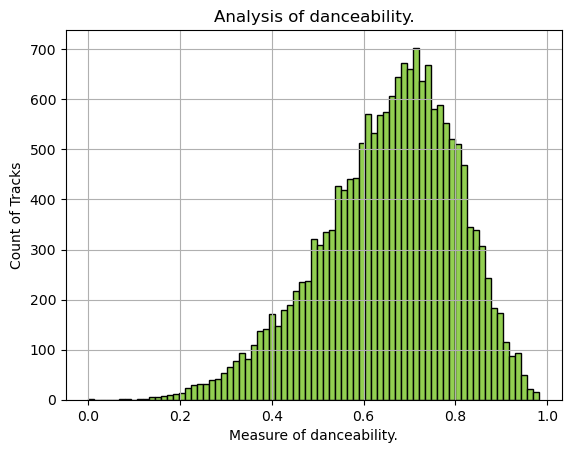

In [35]:
#Danceability mirrors energy of songs very closely keeping to a normal distribution with a slight left skew.
# Creates histograms: 

create_hist()

Enter column name to analyze. energy


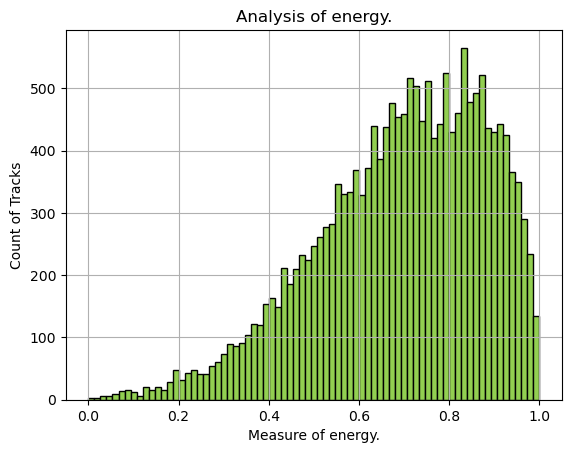

In [36]:
create_hist()

Tempo is a technical measurement. So you are looking at a behavior that is more akin to an artistic norm because it is considered a best practice... 140 BPM. This is the top of the beats per minute, pulse rate, of the human heart; at least a healthy one. So it is what one might expect from being excited which is the emotion that much of pop music is attempting to illicit in listeners. By duplicating the rhythm, they mimic the feeling and illicit the happy feel in listeners. 

Enter column name to analyze. tempo


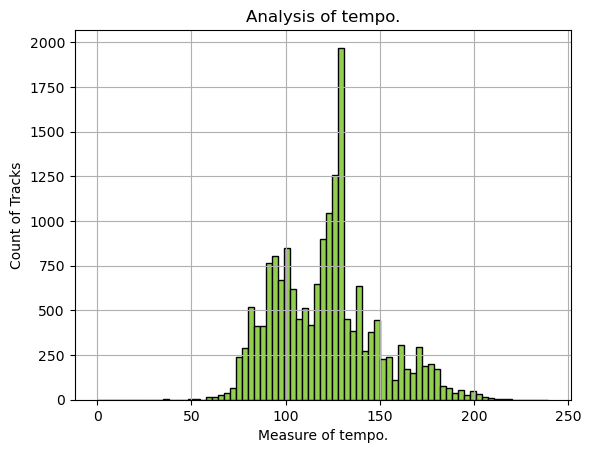

In [37]:
# However tempo does not have a normal distribution because highly energetic / danceable songs, which make up the high density interval, would all keep to
# something of a golden measure of 140 BPM. Slower music less than 100 BPM would sound like a dirge. 
create_hist()

From here we start looking at more in depth information dealing with danceability.... Has it changed over time? Or is it also an industry standard? 

In [44]:
 # Enter the year that is the bottom of the range.
    
attr_report = attr_report_years(1980)

In [45]:
#danceability

genre_plot = create_report()

Enter column name to analyze. danceability


In [46]:
#danceability

genre_plot2 = create_report_gen()

Enter column name to analyze. danceability


In [47]:
#Show the DF

genre_plot

playlist_subgenre,album rock,big room,classic rock,dance pop,electro house,electropop,gangster rap,hard rock,hip hop,hip pop,...,new jack swing,permanent wave,pop edm,post-teen pop,progressive electro house,reggaeton,southern hip hop,trap,tropical,urban contemporary
album_year,,,,,,,,,,,,,,,,,,,,,
1981,0.329000,NaN,0.548385,NaN,NaN,0.679250,NaN,0.480500,NaN,NaN,...,NaN,0.608833,NaN,NaN,0.734000,NaN,0.730500,NaN,NaN,0.706000
1982,0.625667,NaN,0.751667,NaN,NaN,0.784000,NaN,0.609000,NaN,NaN,...,0.733000,0.584600,NaN,0.533000,NaN,NaN,0.947000,NaN,NaN,0.842500
1983,0.638000,NaN,0.557500,NaN,NaN,0.680000,NaN,0.337000,NaN,NaN,...,NaN,0.592538,NaN,NaN,NaN,NaN,0.773000,NaN,NaN,NaN
1984,0.648312,NaN,NaN,NaN,NaN,0.721500,NaN,0.497000,NaN,0.664000,...,0.719000,0.608571,NaN,0.694000,NaN,NaN,0.919000,NaN,NaN,0.470000
1985,0.602600,NaN,0.508000,NaN,NaN,0.561333,NaN,0.411000,NaN,NaN,...,0.547500,0.548200,NaN,NaN,NaN,NaN,0.797000,NaN,NaN,NaN
1986,0.654625,NaN,NaN,NaN,NaN,0.744000,NaN,0.710000,NaN,NaN,...,0.701400,0.606800,NaN,NaN,NaN,NaN,0.791000,NaN,NaN,NaN
1987,0.496154,NaN,0.592600,NaN,NaN,0.715714,NaN,0.390000,NaN,NaN,...,0.781167,0.578636,NaN,NaN,NaN,NaN,0.615667,NaN,NaN,0.592500
1988,0.578857,NaN,0.392667,NaN,NaN,0.754000,0.881000,0.541909,NaN,NaN,...,0.747870,0.603400,NaN,NaN,NaN,NaN,0.759000,NaN,NaN,0.420000
1989,0.411000,NaN,0.518667,NaN,NaN,0.712200,NaN,0.539333,NaN,NaN,...,0.696000,0.549000,NaN,NaN,NaN,NaN,0.824000,NaN,NaN,NaN


In [48]:
#Show the DF

genre_plot2

playlist_genre,edm,latin,pop,r&b,rap,rock
album_year,,,,,,
1981,0.734000,NaN,0.679250,0.543500,0.730500,0.548727
1982,NaN,0.747000,0.616667,0.787750,0.947000,0.631000
1983,NaN,0.862000,0.680000,NaN,0.773000,0.574346
1984,NaN,NaN,0.717571,0.643000,0.919000,0.630417
1985,NaN,0.708000,0.561333,0.547500,0.797000,0.581313
1986,NaN,NaN,0.744000,0.689556,0.791000,0.650062
1987,NaN,0.631667,0.715714,0.726450,0.615667,0.538933
1988,NaN,0.662100,0.754000,0.723577,0.783400,0.546462
1989,NaN,0.645000,0.712200,0.692471,0.824000,0.519333


Plot the information. 

Question: Is music as danceable now as it was in the past? 

Generally over time there is a trend that music becomes less danceable as it moves closer to a 2020 time period. At least for these genres. Specifically, each music, in genre, is less danceable. Are we using music in a different way? 

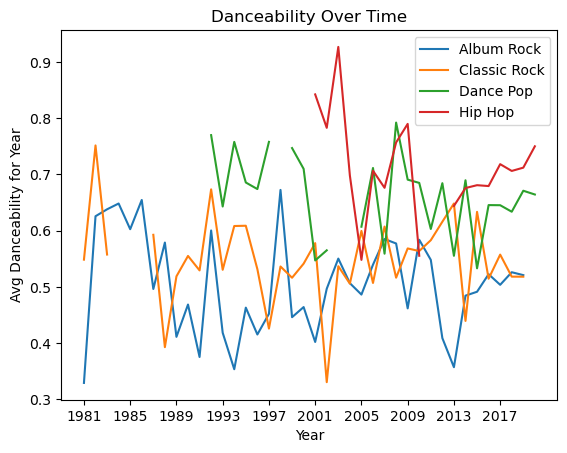

In [49]:
#Plot of danceability over time since 1980, shows that Rock genres are becoming less danceble in deference to pop and Hip Hop. 


# Plotting the lines
plt.plot(genre_plot.index, genre_plot['album rock'], label='Album Rock')
plt.plot(genre_plot.index, genre_plot['classic rock'], label='Classic Rock')
plt.plot(genre_plot.index, genre_plot['dance pop'], label='Dance Pop')
plt.plot(genre_plot.index, genre_plot['hip hop'], label='Hip Hop')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()

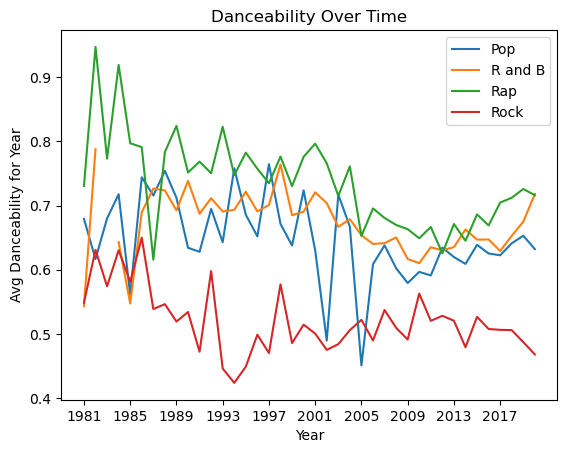

In [50]:
#Plot of danceability over time since 1980, shows that Rock genres are becoming less danceble in deference to Pop and RnB. 
#Strictly speaking however there is a trend of all music becoming less danceable over time. 

# Plotting the lines
plt.plot(genre_plot2.index, genre_plot2['pop'], label='Pop')
plt.plot(genre_plot2.index, genre_plot2['r&b'], label='R and B')
plt.plot(genre_plot2.index, genre_plot2['rap'], label='Rap')
plt.plot(genre_plot2.index, genre_plot2['rock'], label='Rock')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()

It becomes a function of what you are listening to... Latin music, and R and B are more danceable than other categories. So it isn't so much of more, or less, it is a preference choice. If you are a person that dances, then you are listening to different music. So perhaps that's why it is considered more or less danceable. So this is a leading indicator more of a cultural shift, than a market shift. 

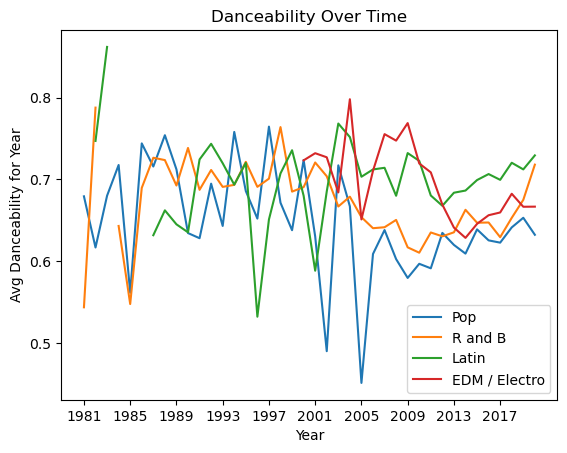

In [51]:
# Plotting the lines
plt.plot(genre_plot2.index, genre_plot2['pop'], label='Pop')
plt.plot(genre_plot2.index, genre_plot2['r&b'], label='R and B')
plt.plot(genre_plot2.index, genre_plot2['latin'], label='Latin')
plt.plot(genre_plot2.index, genre_plot2['edm'], label='EDM / Electro')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()

This code is just to export and move the data that we've made. 

In [ ]:
#Creates a csv in a certain DB

export_csv(genre_plot)

In [17]:
df_to_mongo(my_df)

Specify database. final
Specify collection name. my_df


Database 'final' already exists. Writing to existing database.
Data successfully saved to MongoDB.
